In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv("car_evaluation.csv")

In [4]:
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [5]:
col_names = ["buying", "maintanance", "doors", "persons", "lug_boot","safety", "class"]

In [6]:
df.columns = col_names

In [7]:
df.head()

,buying,maintanance,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   buying       1727 non-null   object
 1   maintanance  1727 non-null   object
 2   doors        1727 non-null   object
 3   persons      1727 non-null   object
 4   lug_boot     1727 non-null   object
 5   safety       1727 non-null   object
 6   class        1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [9]:
for col in df.columns:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maintanance
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [10]:
df.isnull().sum()

buying         0
maintanance    0
doors          0
persons        0
lug_boot       0
safety         0
class          0
dtype: int64

# feature engineering

In [11]:
df["doors"].unique()

array(['2', '3', '4', '5more'], dtype=object)

In [12]:
df["doors"] =df["doors"].replace("5more", "5")

In [13]:
df["doors"].unique()

array(['2', '3', '4', '5'], dtype=object)

In [14]:
df["doors"] = df["doors"].astype(int)

In [15]:
df["persons"].unique()

array(['2', '4', 'more'], dtype=object)

In [16]:
df["persons"] = df["persons"].replace("more", "5")

In [17]:
df["persons"].unique()

array(['2', '4', '5'], dtype=object)

In [18]:
df["persons"] = df["persons"].astype(int)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   buying       1727 non-null   object
 1   maintanance  1727 non-null   object
 2   doors        1727 non-null   int64 
 3   persons      1727 non-null   int64 
 4   lug_boot     1727 non-null   object
 5   safety       1727 non-null   object
 6   class        1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


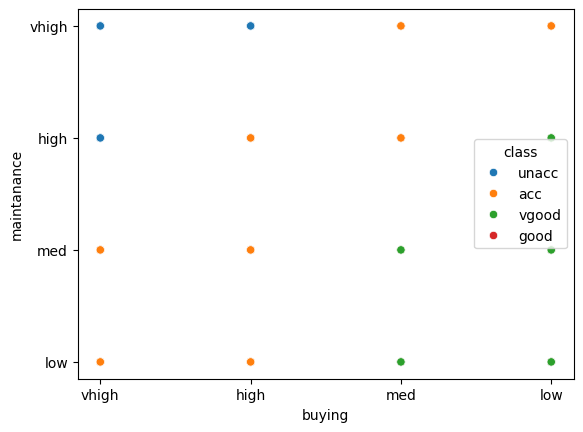

In [63]:
sns.scatterplot(x = df["buying"], y =df ["maintanance"], hue = df["class"])
plt.show()

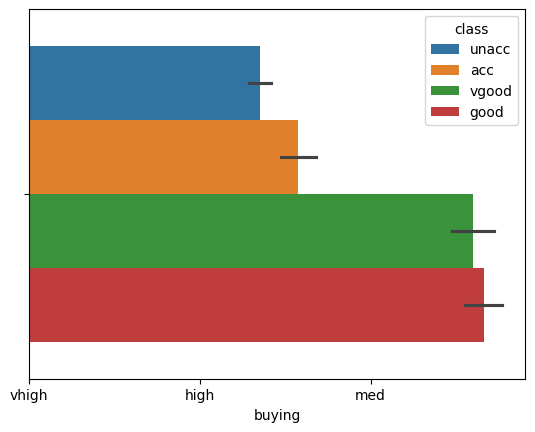

In [21]:
sns.barplot(x = df["buying"],hue = df["class"])
plt.show()

In [22]:
X = df.drop("class", axis = 1)
y = df["class"]

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [25]:
X_train.shape

(1295, 6)

In [26]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [27]:
for col in df.columns:
    print(df[col].unique())

['vhigh' 'high' 'med' 'low']
['vhigh' 'high' 'med' 'low']
[2 3 4 5]
[2 4 5]
['small' 'med' 'big']
['med' 'high' 'low']
['unacc' 'acc' 'vgood' 'good']


In [28]:
categorical_cols = ["buying", "maintanance", "lug_boot", "safety"]
num_cols = ["doors", "persons"]

ordinal_encoder = OrdinalEncoder(categories = [
    ["low", "med", "high", "vhigh"], #buying
    ["low", "med", "high", "vhigh"], #maintanance
    ["small", "med", "big"], #lug_boot
    ["low", "med", "high"] # safety    
])


#farklı columnlara farklı encoding işlemi yapmak için column transfer kullanılır

preprocessor = ColumnTransformer(transformers= [
        ("transform_name", ordinal_encoder, categorical_cols),],
        remainder = "passthrough"    #encode edilmeyen columnları drop etmemek için passthrough yazıyoruz
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [29]:
pd.DataFrame(X_train_transformed)[4].unique()

array([3., 2., 4., 5.])

In [30]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
tree_model = DecisionTreeClassifier(criterion = "gini", max_depth = 5, random_state = 15)
tree_model.fit(X_train_transformed, y_train)

DecisionTreeClassifier(max_depth=5, random_state=15)

In [32]:
y_pred = tree_model.predict(X_test_transformed)

In [33]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report 

In [34]:
print("accuracy score:" , accuracy_score(y_test, y_pred))
print("confusion matrix: \n " , confusion_matrix(y_test, y_pred))
print("classification report: \n", classification_report(y_test,y_pred))

accuracy score: 0.8518518518518519
confusion matrix: 
  [[ 78   0  13   2]
 [ 13   0   0   6]
 [ 26   0 279   0]
 [  4   0   0  11]]
classification report: 
               precision    recall  f1-score   support

         acc       0.64      0.84      0.73        93
        good       0.00      0.00      0.00        19
       unacc       0.96      0.91      0.93       305
       vgood       0.58      0.73      0.65        15

    accuracy                           0.85       432
   macro avg       0.54      0.62      0.58       432
weighted avg       0.83      0.85      0.84       432



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


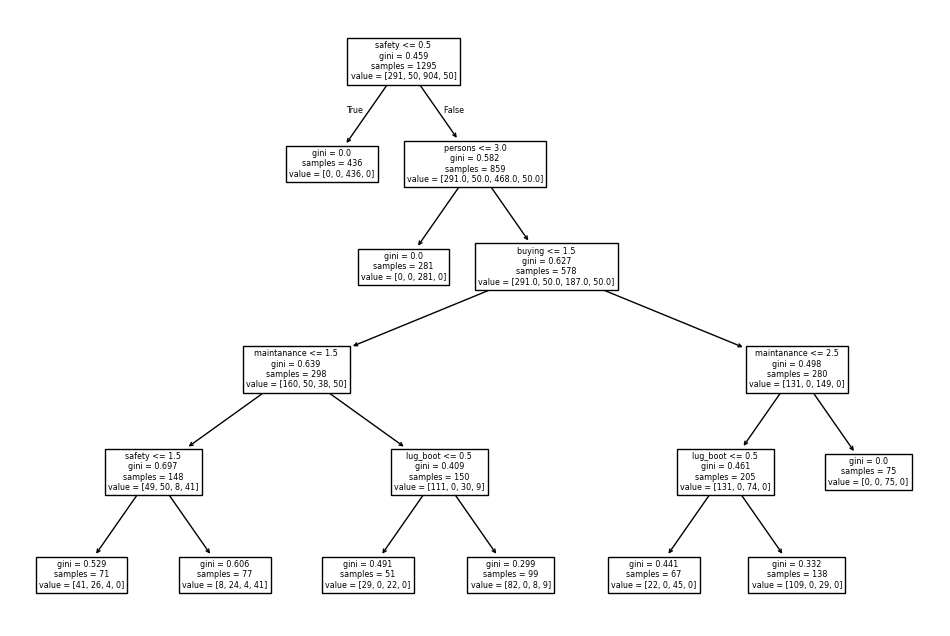

In [35]:
plt.figure(figsize = (12,8))
from sklearn import tree

column_names = categorical_cols + num_cols
tree.plot_tree(tree_model.fit(X_train_transformed,y_train), feature_names= column_names)

plt.show()

In [36]:
# hyperparameter tuning

In [37]:
params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [3,6,9,15,20,None],
    "max_features": ["log2", "sqrt",None]
}

In [38]:
from sklearn.model_selection import GridSearchCV

In [39]:
grid = GridSearchCV(estimator = DecisionTreeClassifier(), param_grid = params, cv = 5, scoring = "accuracy")

In [40]:
import warnings
warnings.filterwarnings("ignore")

grid.fit(X_train_transformed, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [3, 6, 9, 15, 20, None],
                         'max_features': ['log2', 'sqrt', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [41]:
grid.best_params_

{'criterion': 'log_loss',
 'max_depth': 20,
 'max_features': None,
 'splitter': 'best'}

In [42]:
y_pred = grid.predict(X_test_transformed)

In [43]:
print("accuracy score:" , accuracy_score(y_test, y_pred))
print("confusion matrix: \n " , confusion_matrix(y_test, y_pred))
print("classification report: \n", classification_report(y_test,y_pred))

accuracy score: 0.9791666666666666
confusion matrix: 
  [[ 91   0   1   1]
 [  3  16   0   0]
 [  4   0 301   0]
 [  0   0   0  15]]
classification report: 
               precision    recall  f1-score   support

         acc       0.93      0.98      0.95        93
        good       1.00      0.84      0.91        19
       unacc       1.00      0.99      0.99       305
       vgood       0.94      1.00      0.97        15

    accuracy                           0.98       432
   macro avg       0.97      0.95      0.96       432
weighted avg       0.98      0.98      0.98       432



In [44]:
tree_model_new = DecisionTreeClassifier(criterion = "gini", max_depth= 20, max_features = None, splitter = "best")

In [45]:
tree_model_new.fit(X_train_transformed, y_train)


DecisionTreeClassifier(max_depth=20)

In [46]:
y_pred = tree_model_new.predict(X_test_transformed)

In [47]:
print("accuracy score:" , accuracy_score(y_test, y_pred))
print("confusion matrix: \n " , confusion_matrix(y_test, y_pred))
print("classification report: \n", classification_report(y_test,y_pred))

accuracy score: 0.9837962962962963
confusion matrix: 
  [[ 91   0   1   1]
 [  3  16   0   0]
 [  2   0 303   0]
 [  0   0   0  15]]
classification report: 
               precision    recall  f1-score   support

         acc       0.95      0.98      0.96        93
        good       1.00      0.84      0.91        19
       unacc       1.00      0.99      1.00       305
       vgood       0.94      1.00      0.97        15

    accuracy                           0.98       432
   macro avg       0.97      0.95      0.96       432
weighted avg       0.98      0.98      0.98       432



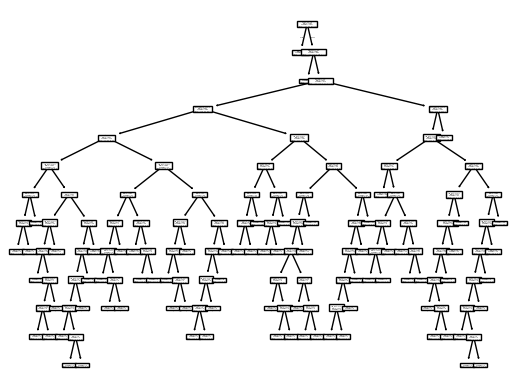

In [48]:
tree.plot_tree(tree_model_new.fit(X_train_transformed,y_train), feature_names= column_names)
plt.show()

In [49]:
import joblib

joblib.dump(tree_model_new, 'decisiontree_model.pkl')

['decisiontree_model.pkl']

# truming with iris dataset

In [50]:
df_new = pd.read_csv("Iris.csv")

In [51]:
df_new.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [52]:
X = df_new.drop(["Id", "Species"], axis = 1)
y = df_new["Species"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [54]:
tree_model = DecisionTreeClassifier()

In [55]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

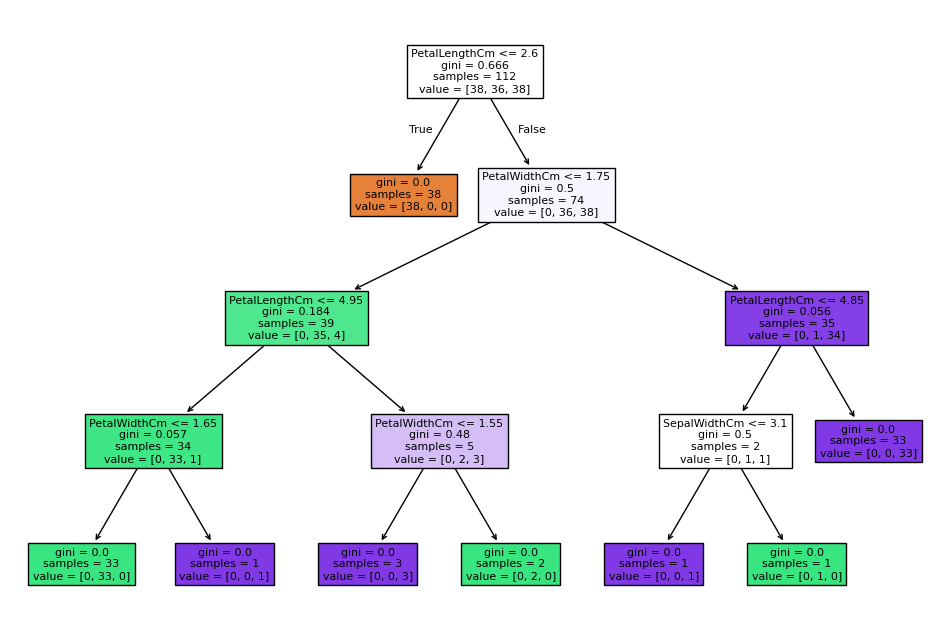

In [56]:
plt.figure(figsize = (12,8))
tree.plot_tree(tree_model.fit(X_train,y_train), feature_names= X_train.columns, filled =True)
plt.show()

In [57]:
y_pred = tree_model.predict(X_test)

In [58]:
print("accuracy score:" , accuracy_score(y_test, y_pred))
print("confusion matrix: \n " , confusion_matrix(y_test, y_pred))
print("classification report: \n", classification_report(y_test,y_pred))

accuracy score: 0.9736842105263158
confusion matrix: 
  [[12  0  0]
 [ 0 14  0]
 [ 0  1 11]]
classification report: 
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.93      1.00      0.97        14
 Iris-virginica       1.00      0.92      0.96        12

       accuracy                           0.97        38
      macro avg       0.98      0.97      0.97        38
   weighted avg       0.98      0.97      0.97        38



In [61]:
#ağaç uzunluğunu azalttık (budadık)
tree_model = DecisionTreeClassifier(max_depth = 2)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)
print("accuracy score:" , accuracy_score(y_test, y_pred))
print("confusion matrix: \n " , confusion_matrix(y_test, y_pred))
print("classification report: \n", classification_report(y_test,y_pred))

accuracy score: 0.9736842105263158
confusion matrix: 
  [[12  0  0]
 [ 0 14  0]
 [ 0  1 11]]
classification report: 
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.93      1.00      0.97        14
 Iris-virginica       1.00      0.92      0.96        12

       accuracy                           0.97        38
      macro avg       0.98      0.97      0.97        38
   weighted avg       0.98      0.97      0.97        38



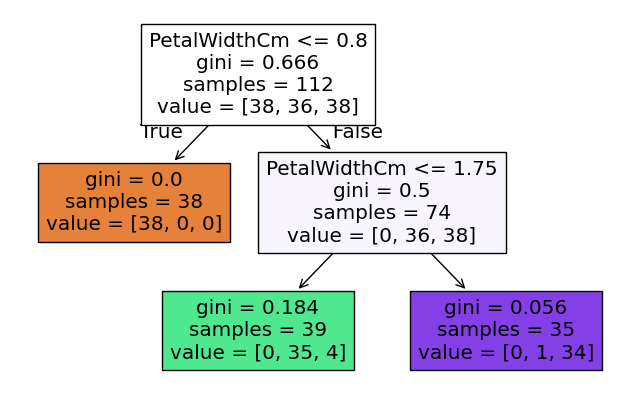

In [62]:
plt.figure(figsize = (8,5))
tree.plot_tree(tree_model.fit(X_train,y_train), feature_names= X_train.columns, filled =True)
plt.show()